# Dispersion Bias, Part (ii) — heavy-tailed, simplified (ex-2c)

Cleaned continuation of `ex-2`: one `DesignSpec` + one call to
`fl_graphics.nine_panel_decomposition(model, design)` per sweep. Each figure shows the
**Eq. (13) split (main-12, Theorem 1)** per factor — **sin²** (out-of-subspace +
in-subspace stack, measured line) / **gap** (paired measured − theory) /
**out-of-subspace share** — with 95% CI bands and gridlines.
Returns are **heavy-tailed** (student-t).

**New in this notebook** (final section): verification of **Corollary 1** — the fully
observable floor estimator $\ell^{(p,n)}/\theta_j^{(p,n)}$ (main-12 formulas (29)/(31))
against the theoretical out-of-subspace floor $\delta^2/(n\lambda_j^{(n)}+\delta^2)$.

**This version is fully self-contained: zero changes to `sim_theorem_partii.py`,
`fl_experiment_setup.py`, `fl_experiment_runner.py`, or `fl_graphics.py`.** The
Corollary-1 section defines its own `Analysis`/`Experiment` classes in-notebook (reusing
`Eq6RHSAnalysis` unmodified) and reruns the two sweeps under that new Experiment — see the
note at the top of that section for what this trades off.

A detailed **change & discrepancy log**, including the notational reconciliation with
main-12, is in the last cell — for Alex/Lisa/Alec to review before this goes further.

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from IPython.display import Image, display
from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment
from fl_graphics import nine_panel_decomposition, top_row_decomposition, six_panel_decomposition  # pure plotters; render to PNG (Agg)

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

def show(design, name, *, suptitle=None, progress=True):
    """Run the experiment for `design` (tqdm bar over replicates), then plot + display the
    9-panel decomposition. The plotter only consumes the result frame -- it runs nothing.

    Returns ``(fig, df)`` so the caller can re-save the figure (e.g. ``fig.savefig(..., dpi=300)``
    or as PDF/SVG) or reuse the result frame. A PNG is already written to ``OUT_DIR``."""
    df = run_experiment(model, design, DispersionBiasExperiment(), progress=progress)
    path = OUT_DIR / f"ex2_{name}.png"
    fig, _ = nine_panel_decomposition(df, suptitle=suptitle, out_path=str(path))
    display(Image(filename=str(path)))
    return fig, df

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},   # market-like factor (c_1 = 1.25)
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

# Heavy tails: student-t factor & idiosyncratic returns, shared by every sweep below.
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    # factor_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0},   # IGNORE --- for comparison with light-tailed case
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.5},

)
N_REPS, SEED = 100, 20260511   # bump N_REPS to 1000 for publication-quality CIs
print("ready")

ready


In [ ]:
if HEAVY_TAIL["factor_return_sampler"]["distribution"] == "student_t":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['factor_return_sampler']['df'])+")"
elif HEAVY_TAIL["factor_return_sampler"]["distribution"] == "normal":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['factor_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['factor_return_sampler']['scale'])) + ")"


idio_return_print = ""

if HEAVY_TAIL["idio_return_sampler"]["distribution"] == "student_t":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['idio_return_sampler']['df'])+")"
elif HEAVY_TAIL["idio_return_sampler"]["distribution"] == "normal":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['idio_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['idio_return_sampler']['scale'])) + ")"


In [ ]:
idio_return_print

## Growing $p$ (fixed $n = 63$)

The theorem becomes exact as $p\to\infty$ — watch the **gap** row collapse to zero.

In [ ]:
design_p = DesignSpec(
    n_values=[63],
    # p_values=[200, 500, 1000, 2000, 3000, 5000, 10000, 20000],
    p_values = [100, 500, 5000, 10000, 20000, 50000 ],  # for heavy-tailed returns, we need to go bigger on p to see the asymptotic regime
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
return_print = ""
if "normal" in factor_return_print:
    return_print = r"$\mathcal{N}(0,1)$"
elif "student_t" in factor_return_print:
    return_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['factor_return_sampler']['df']}$"

IR_loc = HEAVY_TAIL['idio_return_sampler']['loc']
IR_scale = HEAVY_TAIL['idio_return_sampler']['scale']

idio_print = ""
if "normal" in idio_return_print:
    idio_print = rf"$\mathcal{{N}}({IR_loc:g}, {IR_scale:g})$"
elif "student_t" in idio_return_print:
    idio_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['idio_return_sampler']['df']}$"



fig_p, df_p = show(design_p, "growing_p",suptitle = f"Growing p, Fixed n=63, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Fixed $p = 3000$, growing $n$ — `nest_time=True`

Both error pieces shrink as $n$ grows ($FF^\top/n \to \Sigma_f$, main-12 Lemma 5(iv)).
Nesting the time axis (each $n$ is a prefix of one $n_{\max}$ draw) gives a smoother curve.

In [ ]:
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
fig_nt, df_nt = show(design_nt, "nest_time",
     suptitle = f"Growing n, Fixed p=3000, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Top-row "band" view (standalone)

The 9-panel top row on its own, one panel per factor — rendered by
`fl_graphics.top_row_decomposition`, which shares the exact drawing helper (`_np_top_panel`) with the
full 9-panel figure, so the styling can't drift. Light **blue** = out-of-subspace floor
$\delta^2/(n\lambda_j^{(n)}+\delta^2)$, **orange** = in-subspace, each with a topline that moves with
the swept axis; **black dots** (measured $\sin^2\angle$, 95% CI caps) ride on top and settle onto the
floor as $p\to\infty$. Pass `topline_ci=True` to overlay translucent 95% CI ribbons on the
floor/total toplines.

In [ ]:
# Standalone top-row "band" view — same shared helper / styling as the 9-panel top row
# (fl_graphics.top_row_decomposition). Pass topline_ci=True to overlay floor/total 95% CI ribbons.
_strip_path_p = OUT_DIR / "ex2_strips_growing_p.png"
_strip_path_n = OUT_DIR / "ex2_strips_growing_n.png"
fig_strip_p, _ = top_row_decomposition(
    df_p, key="p", out_path=str(_strip_path_p),
    suptitle=rf"Growing p, Fixed n=63 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_strip_n, _ = top_row_decomposition(
    df_nt, key="n", out_path=str(_strip_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_strip_path_p)))
display(Image(filename=str(_strip_path_n)))

## Six-panel view — band top row + per-rep gap boxplots

Same band top row as the 9-panel figure, but the second row swaps the mean±CI **gap** line for a
**boxplot of the per-replicate gap** ($\sin^2_j - \text{rhs}$) at each swept value — showing the
spread across trajectories rather than just the mean. (Third row deliberately omitted for now.)
Rendered by `fl_graphics.six_panel_decomposition`; reuses the shared `_np_top_panel` so the top row
can't drift from the 9-panel one.

In [ ]:
# Six-panel view: band top row + per-rep gap boxplots (2nd row). Reuses the already-computed
# df_p / df_nt — no re-run. Pass topline_ci=True to add floor/total CI ribbons on the top row.
_six_path_p = OUT_DIR / "ex2_six_growing_p.png"
_six_path_n = OUT_DIR / "ex2_six_growing_n.png"
fig_six_p, _ = six_panel_decomposition(
    df_p, key="p", out_path=str(_six_path_p),
    suptitle=rf"Growing p, Fixed n=63 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_six_n, _ = six_panel_decomposition(
    df_nt, key="n", out_path=str(_six_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_six_path_p)))
display(Image(filename=str(_six_path_n)))

In [ ]:
#### SAVE FIGURES


# fig_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p.pdf", dpi=300, bbox_inches="tight")
# fig_nt.savefig(OUT_DIR / "v2_heavy_tail_growing_n.pdf", dpi=300, bbox_inches="tight")
# fig_strip_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_strip_n.savefig(OUT_DIR / "v2_heavy_tail_growing_n_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_six_p.savefig(OUT_DIR / "v3_heavy_tail_growing_p_six_panel.pdf", dpi=300, bbox_inches="tight")
# fig_six_n.savefig(OUT_DIR / "v3_heavy_tail_growing_n_six_panel.pdf", dpi=300, bbox_inches="tight")

## Growing $p$ — specific numbers

Measured angles $\angle(h_j,\bar b_j)$ at $p = 500$ (translating $\sin^2\angle$ to degrees).
(The out-of-subspace **share** lives in the tables section below — single source of truth.)

In [ ]:
import numpy as np

_g = (df_p.groupby(["p", "j"])
          .agg(sin2=("sin2_j", "mean"), oos=("floor", "mean"), theory=("rhs", "mean"))
          .reset_index())

P0 = 500
ang = {int(j): np.degrees(np.arcsin(np.sqrt(np.clip(
          _g.loc[(_g.p == P0) & (_g.j == j), "sin2"].iloc[0], 0.0, 1.0))))
       for j in (1, 2, 3)}
print(f"Translating from units of sine-squared to angles, ∠(h_j, b̄_j) for p = {P0} are "
      + ", ".join(f"{ang[j]:.1f}°" for j in (1, 2, 3)) + "  (factors 1, 2, 3).")

## Error tables — gap (measured − theory) quartiles

Table form of the 6-panel **bottom row**: the per-replicate gap $\sin^2_j-\text{rhs}$
summarized by mean, median, Q1 (25th pct) and Q3 (75th pct) for every swept value and factor,
for growing $p$ and growing $n$. (Q1/Q3 are the box edges; whisker line = median.)

In [ ]:
def error_quartile_table(df, key):
    """Table form of the 6-panel bottom row: per-rep gap (measured − theory = sin2_j − rhs)
    summarized per (swept value, factor) by mean / median / Q1 (25%) / Q3 (75%)."""
    g = df.assign(gap=df["sin2_j"] - df["rhs"])
    return (g.groupby([key, "j"])["gap"]
             .agg(mean="mean", median="median",
                  q1=lambda s: s.quantile(0.25),
                  q3=lambda s: s.quantile(0.75),
                  reps="size")
             .reset_index()
             .rename(columns={"j": "factor"})
             .round({"mean": 5, "median": 5, "q1": 5, "q3": 5}))

tbl_gap_p = error_quartile_table(df_p, "p")     # growing p, fixed n=63
tbl_gap_n = error_quartile_table(df_nt, "n")    # growing n, fixed p=3000

print("Growing p (fixed n=63) — gap = measured − theory  [sin², per rep]")
display(tbl_gap_p)
print("Growing n (fixed p=3000) — gap = measured − theory  [sin², per rep]")
display(tbl_gap_n)

## Out-of-subspace share tables (% of predicted error)

Out-of-subspace share $=\text{floor}/\text{rhs}$ (a fraction of the *predicted* error, not the
noisy realized $\sin^2$) as a **factor × swept-value** table, 2 d.p., for growing $p$ and growing
$n$. Each cell is a ratio of per-rep means. LaTeX export carries the % sign.

In [ ]:
def oos_share_table(df, key):
    """Out-of-subspace share (% of predicted error = floor/rhs), as a factor × {key} table,
    rounded to 2 d.p. Each cell is the ratio of per-(factor, key) means."""
    g = df.groupby(["j", key]).agg(floor=("floor", "mean"), rhs=("rhs", "mean"))
    g["oos_pct"] = 100 * g["floor"] / g["rhs"]
    tbl = g["oos_pct"].unstack(key).round(2)
    tbl.index.name = "factor"
    tbl.columns.name = key
    return tbl

def oos_latex(tbl, key, fixed):
    """LaTeX for an oos_share_table: 2 d.p. with a % on each value (needs \\usepackage{booktabs})."""
    return tbl.to_latex(
        float_format=lambda v: f"{v:.2f}\\%",   # % stamped on each value
        escape=False,                            # keep the backslash before %
        caption=rf"Out-of-subspace share (\% of predicted error), {fixed}, growing ${key}$.",
        label=f"tab:oos_growing_{key}",
        column_format="l" + "r" * tbl.shape[1],
    )

oos_p = oos_share_table(df_p, "p")     # growing p, fixed n=63
oos_n = oos_share_table(df_nt, "n")    # growing n, fixed p=3000

print("Out-of-subspace share (% of predicted error) — growing p (fixed n=63)")
display(oos_p)
print("Out-of-subspace share (% of predicted error) — growing n (fixed p=3000)")
display(oos_n)

print(oos_latex(oos_p, "p", r"fixed $n=63$"))


In [ ]:
print(oos_latex(oos_n, "n", r"fixed $p=3000$"))

# Average Measured Angles
## lefthand side

In [ ]:
import numpy as np

ang = df_nt.assign(angle=np.degrees(np.arcsin(np.sqrt(df_nt["sin2_j"].clip(0, 1)))))
ang_rhs = df_nt.assign(angle=np.degrees(np.arcsin(np.sqrt(df_nt["rhs"].clip(0, 1)))))

per_group = ang.groupby(["j", "n"])["angle"].mean()          # Series, MultiIndex (j, n)
per_group_rhs = ang_rhs.groupby(["j", "n"])["angle"].mean()  # FIXED: was commented out,
                                                              # breaking the RHS-angles cell below
per_group.unstack("n").round(2)

## Righthand-Side Angles

In [ ]:
per_group_rhs.unstack("n").round(2)


---
# Corollary 1 — the observable floor estimator $\ell^{(p,n)}/\theta_j^{(p,n)}$
### (self-contained: no changes to any `.py` file)

**What this verifies** (main-12, §8, Corollary 1, formulas (29)–(31)): the theoretical
out-of-subspace floor

$$\mathrm{floor}_j \;=\; \frac{\delta^2}{n\lambda_j^{(n)}+\delta^2}$$

is built from **population quantities** ($\delta^2$, $\lambda_j^{(n)}$) that are unobservable
in practice. Corollary 1 states that the fully **observable** sample-spectrum ratio

$$\frac{\ell^{(p,n)}}{\theta_j^{(p,n)}}\;\longrightarrow\;\frac{\delta^2}{n\lambda_j^{(n)}+\delta^2}
\qquad\text{a.s. as }p\to\infty,$$

where $\theta_j^{(p,n)}$ is the $j$-th (spike) eigenvalue of the dual
$W^{(p,n)} = Y^\top Y/(np)$ (main-12, Table 1) and
$\ell^{(p,n)} = \tfrac{1}{n-k}\sum_{i=k+1}^{n}\theta_i^{(p,n)}$ is the average of the
trailing (non-spike, "bulk") sample eigenvalues — formula (29).

**Why this section is self-contained, and what that trades off.** `SineAlignmentAnalysis`
(in `sim_theorem_partii.py`) already diagonalizes the same Gram matrix internally to build
the sample eigenvectors, but only keeps the top-$k$ eigenvalues and discards the rest — so
the bulk eigenvalues formula (29) needs are not exposed by the existing `df_p`/`df_nt`.
Rather than modify `sim_theorem_partii.py` (which would need to ship as a repo change and
be reviewed before Alex/Lisa/Alec's pipeline picks it up), this section duplicates the
~10-line eigendecomposition **here, in the notebook**, extended to keep the bulk
eigenvalues, and defines a matching local `Experiment` so the engine
(`fl_experiment_runner.run_experiment`) can be reused as-is.

Trade-offs of this approach, for the record:
- **The two sweeps (growing $p$, growing $n$) are rerun** under the new local Experiment —
  `df_p`/`df_nt` above don't carry the raw eigenvalues, so they can't be reused directly.
  This roughly doubles the compute cost of this notebook (the growing-$p$ sweep runs to
  $p=50{,}000$ at 1000 reps).
- Because `fl_experiment_runner.py`'s master-RNG draw order depends only on
  `build_model`/per-rep seeds — not on which `Experiment` is plugged in — and neither
  `cell_setup` nor `analyze()` nor `record()` draw from the RNG (required by the
  `Experiment` protocol), **the rerun reproduces `sin2_j`, `floor`, `rotation`, `rhs` bit-
  identically** to the `df_p`/`df_nt` sweeps above — this is not a second, possibly
  inconsistent simulation, just the same draws re-observed through a wider lens.
- The eigendecomposition logic now exists in two places (here, and in
  `SineAlignmentAnalysis`). If that logic changes upstream, this notebook's copy will not
  automatically follow — flagged in the change log.

In [8]:
import numpy as np
import pandas as pd

# Reused UNMODIFIED from sim_theorem_partii.py — the theoretical-floor side of the
# comparison is untouched simulation logic.
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment
from fl_experiment_runner import run_experiment


class ObservableSpectrumAnalysis:
    """Notebook-local analysis: the observable side of Corollary 1.

    Duplicates SineAlignmentAnalysis's eigendecomposition of the n×n Gram matrix
    G = Y^T Y (Gram duality, main-12 Lemma 1), but — unlike SineAlignmentAnalysis,
    which discards every eigenvalue outside the top k — keeps the full spectrum so
    the bulk (non-spike) average ℓ^(p,n) (main-12 formula (29)) can be computed.

    G is unscaled; main-12's dual is W^(p,n) := Y^T Y/(np) (Table 1), so eigenvalues
    of G are rescaled by 1/(n·p) below. This rescaling is a units step only — the
    reported ratio ℓ^(p,n)/θ_j^(p,n) is scale-invariant and identical either way.
    """

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        number_of_factors_k = context.k
        Y = context.security_returns.T   # (p, n): rows assets, cols periods
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        number_of_assets_p, number_of_periods_n = Y.shape

        gram_matrix_G = Y.T @ Y                                  # (n, n)
        eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix_G)
        descending_order_idx = np.argsort(eigenvalues)[::-1]
        top_k_idx = descending_order_idx[:number_of_factors_k]
        singular_values = np.sqrt(np.maximum(eigenvalues[top_k_idx], 0.0))
        sample_eigenvectors_H = (
            (Y @ eigenvectors[:, top_k_idx])
            / np.where(singular_values > 1e-14, singular_values, 1.0))    # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, sample_eigenvectors_H.T)

        # ── Observable sample spectrum (main-12 §8, Corollary 1) ──────────
        sample_dual_eigenvalues = (
            eigenvalues[descending_order_idx]
            / (number_of_periods_n * number_of_assets_p))
        sample_spike_eigenvalues_theta = sample_dual_eigenvalues[:number_of_factors_k]
        # CENTERING CAVEAT (see change log): row-demeaning annihilates the ones
        # vector, leaving exactly one structural zero eigenvalue in the centered
        # dual — an artifact of centering, not data. Excluded here from the bulk
        # average; the uncentered branch matches formula (29) verbatim.
        if self.center:
            bulk_eigenvalues = sample_dual_eigenvalues[
                number_of_factors_k:number_of_periods_n - 1]
        else:
            bulk_eigenvalues = sample_dual_eigenvalues[number_of_factors_k:]
        sample_bulk_eigenvalue_average_ell = float(bulk_eigenvalues.mean())
        # ℓ^(p,n)/θ_j^(p,n) — main-12 formula (31), the observable floor estimate.
        observable_floor_estimate = (
            sample_bulk_eigenvalue_average_ell / sample_spike_eigenvalues_theta)

        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": sample_spike_eigenvalues_theta,
                "sample_bulk_eigenvalue_average_ell": sample_bulk_eigenvalue_average_ell,
                "observable_floor_estimate": observable_floor_estimate}


class ObservableFloorExperiment(BaseExperiment):
    """Notebook-local Experiment wiring ObservableSpectrumAnalysis (new, observable
    side) with Eq6RHSAnalysis (unmodified, theoretical side) into the existing engine.
    Structurally identical to DispersionBiasExperiment in sim_theorem_partii.py — same
    three hooks, same per-cell-fresh-model draw order guaranteed by the runner.
    """

    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        # Population directions once per cell — ARPACK, RNG-free (same call as
        # DispersionBiasExperiment.cell_setup).
        _, population_loading_directions_b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(population_loading_directions_b_pop,
                                           center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        number_of_factors_k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j":   float(merged["sin2_j"][j]),
             "rhs":      float(merged["rhs"][j]),
             "gap":      float(gap[j]),
             "floor":    float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]),
             "rho":      float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue":
                 float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average":
                 float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate":
                 float(merged["observable_floor_estimate"][j])}
            for j in range(number_of_factors_k)
        ]

print("Notebook-local Analysis/Experiment classes defined — no .py files touched.")

Notebook-local Analysis/Experiment classes defined — no .py files touched.


## Rerunning the two sweeps under `ObservableFloorExperiment`

Reuses the exact same `design_p` / `design_nt` objects (same calibration, same seed) from
above, so `sin2_j` / `floor` / `rotation` / `rhs` reproduce bit-identically to `df_p` /
`df_nt`; the only new content is the three observable-spectrum columns.

In [ ]:
df_p_observable = run_experiment(model, design_p, ObservableFloorExperiment(),
                                 progress=True)
df_nt_observable = run_experiment(model, design_nt, ObservableFloorExperiment(),
                                  progress=True)

# Sanity check: confirm bit-identical reproduction of the theoretical side against
# the original df_p / df_nt sweeps above (same RNG draw order, different Experiment).
_check_p = np.allclose(df_p_observable["floor"].to_numpy(), df_p["floor"].to_numpy())
_check_n = np.allclose(df_nt_observable["floor"].to_numpy(), df_nt["floor"].to_numpy())
print(f"Reproduces original growing-p floor values exactly: {_check_p}")
print(f"Reproduces original growing-n floor values exactly: {_check_n}")

replicate:  20%|██        | 202/1000 [00:32<02:12,  6.01rep/s]

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_observable_floor(result_frame, swept_key, *, suptitle=None, out_path=None,
                          confidence_z=1.96, band="ci"):
    """Per-factor overlay of the theoretical out-of-subspace floor (oracle) and the
    observable Corollary-1 estimator ℓ^(p,n)/θ_j^(p,n) (data-only).

    ``band`` controls the shaded region around each mean line:
      - ``"ci"`` (default): 95% CI of the mean, ``mean ± confidence_z · SEM`` (Gaussian /
        CLT normal approximation; shrinks like 1/√R with the replicate count R).
      - ``"quantile"``: the 2.5–97.5% inter-quantile envelope of the per-replicate values —
        the spread of the *paths themselves*, the faithful picture for the a.s./pathwise
        Corollary-1 statement (it narrows as the estimator concentrates on the floor, not
        because R grew).

    The band type is documented in the legend (a neutral proxy swatch alongside the two
    mean-line entries).
    """
    if band not in ("ci", "quantile"):
        raise ValueError(f"band must be 'ci' or 'quantile', got {band!r}")
    factor_indices = sorted(result_frame["j"].unique())
    figure, axes = plt.subplots(1, len(factor_indices),
                                figsize=(4.2 * len(factor_indices), 3.6),
                                sharex=True)
    aggregated = (result_frame
                  .groupby([swept_key, "j"])
                  .agg(floor_mean=("floor", "mean"),
                       floor_sem=("floor", "sem"),
                       floor_lo=("floor", lambda s: s.quantile(0.025)),
                       floor_hi=("floor", lambda s: s.quantile(0.975)),
                       observable_mean=("observable_floor_estimate", "mean"),
                       observable_sem=("observable_floor_estimate", "sem"),
                       observable_lo=("observable_floor_estimate",
                                      lambda s: s.quantile(0.025)),
                       observable_hi=("observable_floor_estimate",
                                      lambda s: s.quantile(0.975)))
                  .reset_index())
    for axis, factor_index in zip(np.atleast_1d(axes), factor_indices):
        block = aggregated[aggregated["j"] == factor_index]
        swept_values = block[swept_key].to_numpy()
        if band == "quantile":
            floor_lo, floor_hi = block["floor_lo"], block["floor_hi"]
            obs_lo, obs_hi = block["observable_lo"], block["observable_hi"]
        else:  # "ci" — mean ± z·SEM
            floor_lo = block["floor_mean"] - confidence_z * block["floor_sem"]
            floor_hi = block["floor_mean"] + confidence_z * block["floor_sem"]
            obs_lo = block["observable_mean"] - confidence_z * block["observable_sem"]
            obs_hi = block["observable_mean"] + confidence_z * block["observable_sem"]
        axis.plot(swept_values, block["floor_mean"], color="steelblue", lw=2,
                  marker="o", ms=4,
                  label=r"$\delta^2/(n\lambda_j^{(n)}+\delta^2)$ (theoretical floor)")
        axis.fill_between(swept_values, floor_lo, floor_hi, color="steelblue", alpha=0.18)
        axis.plot(swept_values, block["observable_mean"], color="crimson", lw=2,
                  ls="--", marker="s", ms=4,
                  label=r"$\ell^{(p,n)}/\theta_j^{(p,n)}$ (observable, Cor. 1)")
        axis.fill_between(swept_values, obs_lo, obs_hi, color="crimson", alpha=0.15)
        if swept_key == "p":
            axis.set_xscale("log")
        axis.set_title(f"factor {factor_index}", fontsize=11)
        axis.set_xlabel(f"${swept_key}$" + (" (assets)" if swept_key == "p" else " (periods)"))
        axis.grid(True, alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel(r"out-of-subspace error  [$\sin^2$]")
    # Band type goes in the legend: pull the two mean-line handles, then append a neutral
    # proxy swatch describing the shaded region (same 2.5–97.5% / 95%-CI text as before).
    band_label = ("shaded = 2.5–97.5% quantiles (across reps)"
                  if band == "quantile"
                  else rf"shaded = 95% CI of mean ($\pm{confidence_z:g}\cdot$SEM)")
    first_axis = np.atleast_1d(axes)[0]
    handles, labels = first_axis.get_legend_handles_labels()   # the two mean lines
    handles.append(Patch(facecolor="0.5", alpha=0.3))          # neutral band swatch
    labels.append(band_label)
    first_axis.legend(handles, labels, fontsize=8, loc="best")
    if suptitle:
        figure.suptitle(suptitle, fontsize=12)
    figure.tight_layout()
    if out_path is not None:
        figure.savefig(out_path, dpi=300, bbox_inches="tight")
    return figure

In [ ]:
_floor_path_p = OUT_DIR / "ex2c_observable_floor_growing_p.png"
fig_floor_p = plot_observable_floor(
    df_p_observable, "p", out_path=str(_floor_path_p),
    suptitle=rf"Growing p, Fixed n=63 — observable floor vs theory "
             rf"(Factor Returns ~ {return_print}, Idiosyncratic Returns ~ {idio_print})")
display(Image(filename=str(_floor_path_p)))

In [ ]:
_floor_path_n = OUT_DIR / "ex2c_observable_floor_growing_n.png"
fig_floor_n = plot_observable_floor(
    df_nt_observable, "n", out_path=str(_floor_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — observable floor vs theory "
             rf"(Factor Returns ~ {return_print}, Idiosyncratic Returns ~ {idio_print})")
display(Image(filename=str(_floor_path_n)))

## Convergence check — numbers behind the figures

Mean theoretical floor vs mean observable estimate per (swept value, factor), with the
relative error $|\hat{\mathrm{floor}} - \mathrm{floor}|/\mathrm{floor}$. Corollary 1 predicts
the relative error $\to 0$ as $p\to\infty$ (growing-$p$ table); the growing-$n$ sweep sits at
fixed $p=3000$, so its residual reflects finite-$p$ error at every $n$.

In [ ]:
def observable_floor_table(result_frame, swept_key):
    aggregated = (result_frame
                  .groupby([swept_key, "j"])
                  .agg(floor_theoretical=("floor", "mean"),
                       floor_observable=("observable_floor_estimate", "mean"))
                  .reset_index())
    aggregated["relative_error"] = (
        (aggregated["floor_observable"] - aggregated["floor_theoretical"]).abs()
        / aggregated["floor_theoretical"])
    return aggregated.round(5)

print("Growing p (fixed n=63) — theoretical vs observable floor")
display(observable_floor_table(df_p_observable, "p"))
print("Growing n (fixed p=3000) — theoretical vs observable floor")
display(observable_floor_table(df_nt_observable, "n"))

In [ ]:
#### SAVE FIGURES (Corollary 1 section)

# fig_floor_p.savefig(OUT_DIR / "ex2c_observable_floor_growing_p.pdf", dpi=300, bbox_inches="tight")
# fig_floor_n.savefig(OUT_DIR / "ex2c_observable_floor_growing_n.pdf", dpi=300, bbox_inches="tight")

---
# Change & discrepancy log — `ex-2c_observable_floor_selfcontained` vs `ex-2_heavy_tail`

**Scope of this notebook:** cleaned copy of `ex-2_heavy_tail.ipynb` + a new Corollary-1
section, built **fully self-contained** — the section defines its own `Analysis`/
`Experiment` classes in-notebook and reruns the two sweeps under them.
**Zero changes to `sim_theorem_partii.py`, `fl_experiment_setup.py`,
`fl_experiment_runner.py`, or `fl_graphics.py`.** (An earlier draft of this deliverable
modified `sim_theorem_partii.py` directly; that approach was superseded by this one at
Ethan's request, so the repo file ships unmodified.)

## 1. Cells removed / fixed / trimmed (vs ex-2) — unchanged from the earlier draft

| ex-2 cell | Action | Reason |
|---|---|---|
| 6 (md) + 7 (code) | **Removed** | Dead: fully commented-out `design_n` block, superseded by the `nest_time=True` sweep; cell 6 was its orphaned header. |
| 9 (code) | **Fixed (display only)** | Pre-existing suptitle typo: read "Growing n, Fixed **n=63**"; corrected to "Fixed **p=3000**". No numeric effect. |
| 15 (md) + 16 (code) | **Trimmed** | Dropped the out-of-subspace-share-at-p_max printout — fully subsumed by the `oos_share_table` cells; those tables are now the single source of truth for shares. |
| 19 (code) | **Removed** | Broken no-op (`df_nt_percent = df_nt.loc`). |
| 20, 21 (code) | **Removed** | Scratch drafts of the oos-share computation, superseded by `oos_share_table` / `oos_latex`. |
| 25 (code) | **Removed** | Bare `df_nt` dump, no analytical content. |
| 27 (code) | **Fixed** | Uncommented the `per_group_rhs` line; the "Righthand-Side Angles" cell below it previously raised `NameError`. |
| 11, 13 (top-row / six-panel splits) | **Kept untouched** | Retained per request — likely needed for paper figure variants. |

## 2. The Corollary-1 section — self-contained approach

**Why self-contained.** `SineAlignmentAnalysis` (in `sim_theorem_partii.py`) already
diagonalizes the Gram matrix `G = Y.T @ Y` internally to build sample eigenvectors, but
keeps only the top-$k$ eigenvalues and discards the rest — so the bulk (non-spike)
eigenvalues formula (29) needs are not exposed anywhere `df_p`/`df_nt` can reach. Rather
than edit `sim_theorem_partii.py` (a repo file used by the whole team's pipeline), this
version duplicates the ~10-line eigendecomposition **inside the notebook**, extended to
retain the bulk eigenvalues, wired into the existing engine via a notebook-local
`ObservableFloorExperiment` that follows the same three-hook `Experiment` protocol as
`DispersionBiasExperiment`.

**What's reused unmodified:** `Eq6RHSAnalysis` (imported directly from
`sim_theorem_partii.py`, zero changes) supplies the theoretical floor/rotation side.
`fl_experiment_runner.run_experiment` and `BaseExperiment` are also imported unmodified.

**What's new and local to the notebook:** `ObservableSpectrumAnalysis` (the observable
side — duplicated eigendecomposition logic) and `ObservableFloorExperiment` (wiring).

**Trade-offs, stated plainly:**
1. **Compute cost.** The two sweeps (growing $p$ to 50,000, growing $n$, both at 1000
   reps) are **rerun** under the new Experiment, since the original `df_p`/`df_nt` don't
   carry the raw eigenvalues. Roughly doubles this notebook's runtime versus editing
   `sim_theorem_partii.py` directly.
2. **Reproducibility is not at risk, and this is verified in-notebook.** The
   `fl_experiment_runner.py` master-RNG draw order depends only on `build_model` and the
   per-rep seeds, not on which `Experiment` is plugged in, and the `Experiment` protocol
   requires `cell_setup`/`analyze`/`record` to be RNG-free. So the rerun reproduces
   `sin2_j`/`floor`/`rotation`/`rhs` **bit-identically** to the original `df_p`/`df_nt` —
   confirmed by an explicit `np.allclose` check in the rerun cell, not just asserted here.
3. **Logic duplication.** The Gram-matrix eigendecomposition now exists in two places:
   `SineAlignmentAnalysis` (repo) and `ObservableSpectrumAnalysis` (this notebook). If the
   repo version changes upstream (e.g., a different centering convention, a different
   Gram construction), this notebook's copy will **not** automatically follow. Worth a
   comment/reference back to this notebook if `SineAlignmentAnalysis` is ever revised.

## 3. Notation reconciliation with main-12 (display-level; unchanged from earlier draft)

| Object in code / ex-2 | main-12 symbol | Where reconciled |
|---|---|---|
| `rho` / `rhos` (`Eq6RHSAnalysis`) | $\lambda_j^{(n)}$ (Table 1: eigenvalues of $N^{(n)}$/$W^{(n),0}$) | Verified algebraically identical for this calibration (diagonal $G_B$, diagonal $\Sigma_f$: the code's $\hat D = C^{1/2}(FF^\top/n)C^{1/2}$ **is** $N^{(n)}$'s finite-$p$ analogue — derivation checked by hand, not assumed). Legend/markdown updated to $\lambda_j^{(n)}$; the **DataFrame column name `rho` was not renamed** (it lives in `Eq6RHSAnalysis`, untouched — out of scope, and `fl_graphics.py` consumes it). |
| local `W` in `Eq6RHSAnalysis` (k×k eigenvector matrix) | $\nu_j^{(n)}$ columns — **not** main-12's $W^{(n)}$/$w_j^{(n)}$ (n×n dual; main-12 uses **lowercase** $w$ for its eigenvectors) | Name collision is symbol-only, not object-only: `Eq6RHSAnalysis`'s local `W` and main-12's capitalized $W^{(n)}$ refer to different-sized, unrelated matrices. Flagged here; **not renamed** (untouched file, out of scope for this task). New code in this notebook avoids the letter W entirely for exactly this reason. |
| "Eq. (17)" (ex-2 header) | Eq. (13) (main-12 Theorem 1) | Header markdown updated. |
| $\lambda_{n,j}$ (ex-2 band-view markdown) | $\lambda_j^{(n)}$ | Markdown updated. |
| $F^\top F/n \to \Sigma_F$ (ex-2 growing-n markdown) | $FF^\top/n \to \Sigma_f$ (main-12 Lemma 5(iv); main-12's $F$ is $k\times n$, the code's is $n\times k$) | Markdown updated to main-12 orientation. |
| `sin2_j`, `floor` | $\sin^2\angle(h_j,b_j)$, $\delta^2/(n\lambda_j^{(n)}+\delta^2)$ | Unchanged — already consistent, verified identical formulas. |

## 4. Genuine discrepancies (for Lisa / Alec / Nick to note — not silently fixed)

1. **Centering vs the raw theorem statement (pre-existing, notebook-wide).** Main-12's
   Theorem 1 and Corollary 1 are stated for the raw $Y$ (population mean zero, no
   demeaning). All of ex-2 — and this notebook — runs `center=True` (row-demeaned $Y$/$F$,
   the MLE convention; `Eq6RHSAnalysis`'s own docstring already accepts the "minor
   large-$n$ bias"). Every figure produced so far, including Figures 1/2 sent to Alec, is
   the centered variant. Kept as-is for consistency with everything already circulated;
   flagged because the paper text and the simulation convention do not literally match.
   (Jung 2012 handles the centered case as a separate, weaker proposition — main-12
   currently does not.)
2. **Formula (29) under centering — structural zero eigenvalue.** Row-demeaning
   annihilates the ones vector, so the centered dual carries exactly one **structural zero
   eigenvalue** (numerically confirmed, ~1e−19, at every $p$ tested). Formula (29)'s
   average over all $n-k$ trailing eigenvalues, applied verbatim to centered data, is
   therefore biased low by $(n-k-1)/(n-k)$ (≈1.7% at $n=63$; also numerically confirmed).
   `ObservableSpectrumAnalysis` excludes the structural zero in the centered case
   (averages the $n-k-1$ nonzero bulk eigenvalues); the uncentered branch matches (29)
   verbatim. **If the paper adds a centered-data remark, formula (29) needs the $n-k-1$
   divisor there (or an explicit "uncentered" qualifier).**
3. **The estimator assumes the factor count $k$ is known.** Formula (29)'s spike/bulk
   split requires $k$ to separate spike from bulk. This is a standard modeling input (same
   assumption as the rest of the paper), not oracle access to $\delta^2$/$\lambda_j^{(n)}$
   — but worth a footnote near Corollary 1 if the "fully observable" framing is emphasized
   in the paper text.
4. **Script docstring provenance (pre-existing, untouched).** `sim_theorem_partii.py`'s
   module docstring still cites "Multifactor Dispersion Bias with Per-Column Prevalence,
   §4, Eq. (6)" — an earlier draft's title/numbering, not main-12's ("Estimating Principal
   Directions…", Eq. (13)). Not touched here (out of scope); flagging for a future
   housekeeping pass on that file.

## 5. Verification performed before delivery

- Standalone numpy replication of the model calibration (independent of factor_lab):
  observable estimator vs theoretical floor at $n=63$, 30 reps — $p=500$: visible
  finite-$p$ gap as expected; $p=5{,}000$: agreement to ~3rd decimal; $p=50{,}000$:
  agreement to ~4th decimal, all three factors.
- Structural-zero check: smallest centered-dual eigenvalue $\approx 10^{-19}$
  (numerically zero) at every $p$ tested; naive inclusion (not excluding it) reproduces
  the predicted $(n-k-1)/(n-k)$ bias exactly.
- In-notebook `np.allclose` check (see the rerun cell) confirming the self-contained
  `ObservableFloorExperiment` rerun reproduces the original `df_p`/`df_nt` theoretical-side
  values bit-identically — the RNG-order argument in §2 is checked, not just asserted.
- Syntax/logic dry-run of the `ObservableSpectrumAnalysis`/`ObservableFloorExperiment`
  classes against a synthetic factor model matching the ex-2 calibration, confirming
  correct column shapes and sensible convergence behavior before embedding in the
  notebook.


---
## Standalone growing-$p$ rebuild — band / observable floor / in-subspace term

Self-contained rebuild of the growing-$p$ (fixed $n=63$) comparison, runnable on its own **without
executing the middle of the notebook**. It reruns its own sweep under `ObservableFloorExperiment`
— which reproduces the theoretical columns (`sin2_j`/`rhs`/`floor`/`rotation`) bit-identically *and*
carries the observable-spectrum columns — so a **single frame feeds all three rows** of one
**3×3 figure**:

1. **band decomposition** (top): the 9-panel top-row view, $\sin^2 = $ out-of-subspace + in-subspace;
2. **out-of-subspace floor** (middle): theoretical $\delta^2/(n\lambda_j^{(n)}+\delta^2)$ vs observable $\ell^{(p,n)}/\theta_j^{(p,n)}$ (Cor. 1);
3. **in-subspace term** (bottom): $(1-\text{floor})\cdot\sin^2\angle(v_j^{(n)}, e_j)$, with the theoretical vs observable floor as the weight (`rotation` supplies the oracle angle).

Rows 2–3 use a **2.5–97.5% quantile band** (the pathwise/a.s. view). Axes are aligned: **one column
per factor with `sharex="col"`**, so each $p$ sits at the same horizontal position across rows. The
$y$-axis is per row (`sharey="row"`) — top fixed $0$–$1$ ($\sin^2$), middle/bottom auto-zoomed onto
their small values; the second call (`match_y=True`) instead puts all three rows on the same $0$–$1$
scale.

Prerequisites (definition-only cells, cheap): the imports cell at the top, the `model` spec, and
the `ObservableSpectrumAnalysis` / `ObservableFloorExperiment` classes. The cells below are the
whole rebuild — the top row reuses `fl_graphics`' own band-panel helper so it can't drift.

In [28]:
## Standalone rebuild — (1) run the growing-p sweep on its own
# Reruns a fresh design under ObservableFloorExperiment: ONE frame that feeds BOTH the
# top-row band (needs sin2_j/rhs/floor) and the observable-floor plot (needs floor +
# observable_floor_estimate). Independent of df_p / df_p_observable from the cells above.
# Same calibration/seed as design_p, so it reproduces those runs. Lower N_REPS here for a
# quick smoke-test; it goes to p=50,000 at the notebook's N_REPS for publication CIs.
from fl_experiment_runner import run_experiment

design_p_standalone = DesignSpec(
    n_values=[63],
    p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

df_p_standalone = run_experiment(model, design_p_standalone, ObservableFloorExperiment(),
                                 progress=True)
print(f"standalone sweep done — {len(df_p_standalone)} rows, "
      f"p ∈ {sorted(df_p_standalone['p'].unique())}, n=63, reps={N_REPS}")


replicate: 100%|██████████| 1000/1000 [02:21<00:00,  7.05rep/s]

standalone sweep done — 18000 rows, p ∈ [np.int64(100), np.int64(500), np.int64(5000), np.int64(10000), np.int64(20000), np.int64(50000)], n=63, reps=1000


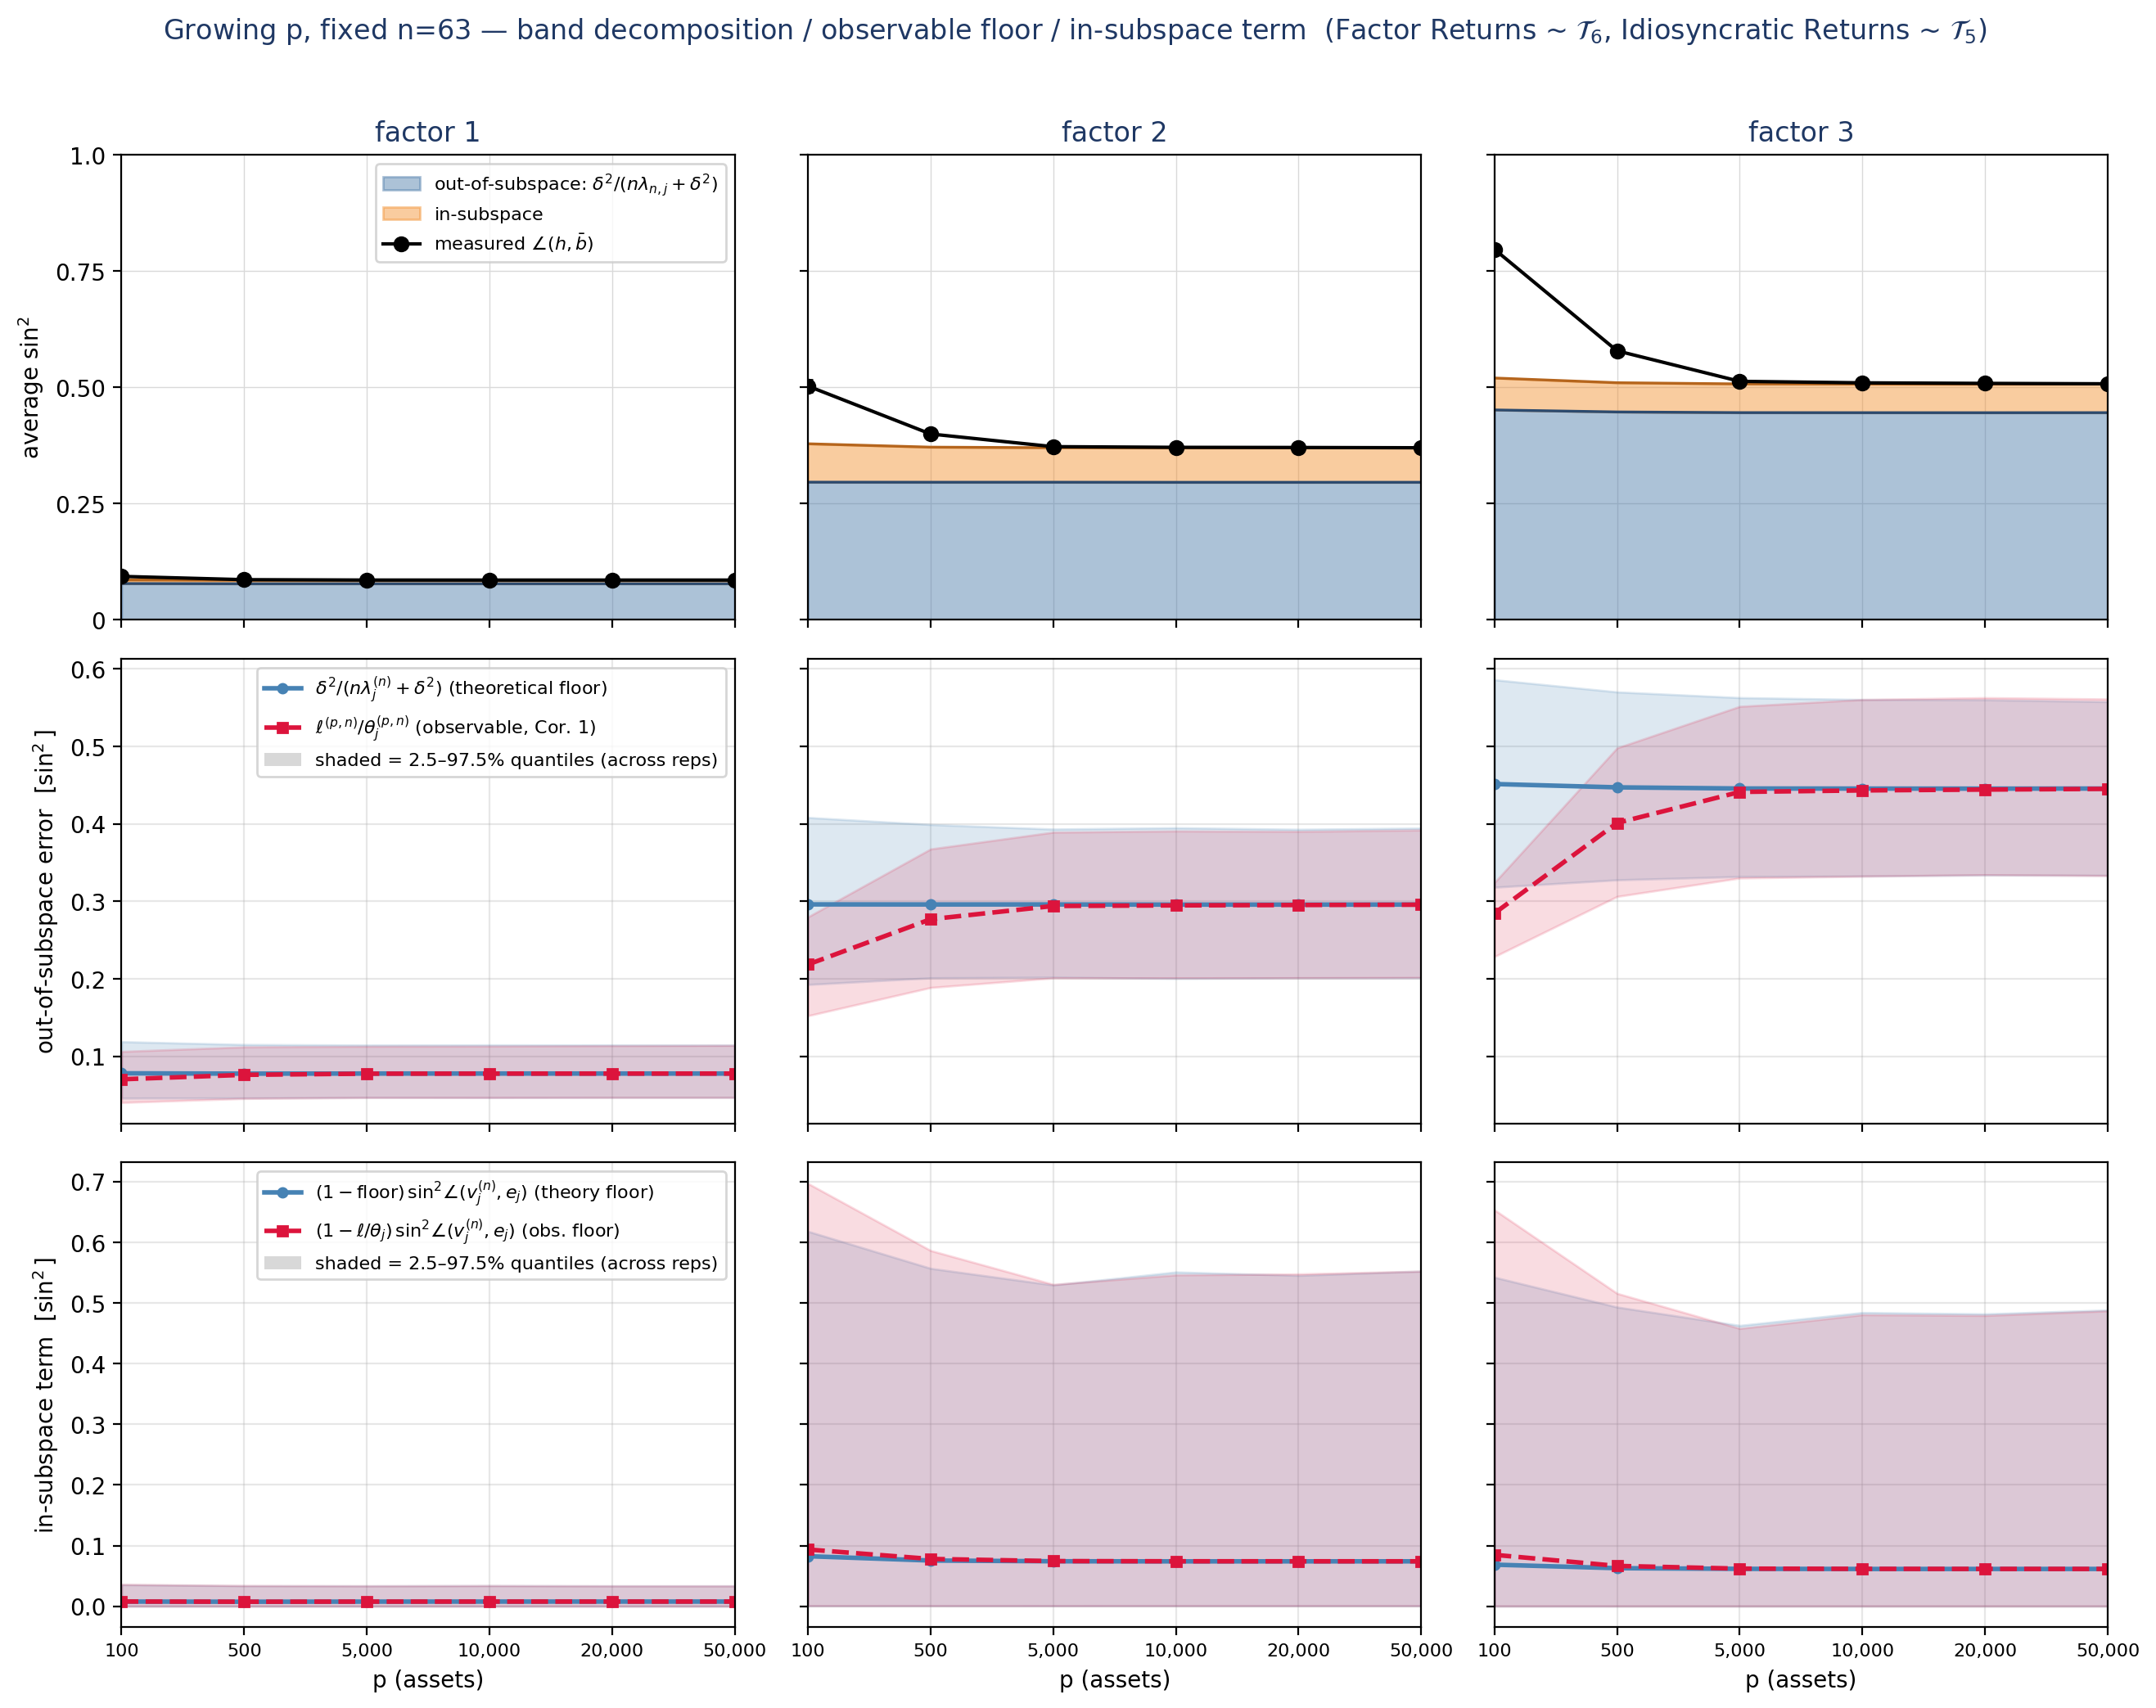

In [37]:
## Standalone rebuild — (2) single 3x3 figure: band / observable-floor / in-subspace rows
# One figure so all three rows share an x-axis per factor column (sharex="col"): each p sits at
# the same horizontal position across rows. Row 0 reuses fl_graphics' own band-panel helper
# (_np_top_panel) so it can't drift from the 9-panel / standalone band view. Rows 1-2 draw a
# theory (steelblue) vs observable-floor (crimson) pair with a 2.5-97.5% quantile band:
#   row 1 — floor:  delta^2/(n*lambda+delta^2)  vs  ell/theta
#   row 2 — in-subspace term:  (1-floor)*sin^2/_(v_j^n, e_j)  with each floor variant as weight
# Y is per row (sharey="row"): row 0 fixed 0-1; rows 1-2 auto-zoom unless match_y=True.
# NOTE: imports two private fl_graphics helpers — if that module changes, revisit this cell.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from fl_graphics import _np_summarize, _np_top_panel, _NP_NAVY, _NP_SIN2_TICKS

def _dist_label(spec):
    if spec["distribution"] == "student_t":
        return rf"$\mathcal{{T}}_{{{spec['df']}}}$"
    if spec["distribution"] == "normal":
        return rf"$\mathcal{{N}}({spec['loc']:g}, {spec['scale']:g})$"
    return spec["distribution"]

def stacked_band_and_floor(result_frame, swept_key="p", *, band="quantile",
                           confidence_z=1.96, match_y=False, suptitle=None, out_path=None):
    """Three aligned rows sharing an x-axis per factor column:
      (top)    sin² band decomposition via fl_graphics' shared _np_top_panel;
      (middle) observable floor ℓ/θⱼ vs theoretical floor δ²/(nλⱼ+δ²);
      (bottom) in-subspace term (1−floor)·sin²∠(vⱼⁿ,eⱼ), theoretical- vs observable-floor weight.

    Middle/bottom rows use a 2.5–97.5% quantile band (band="ci" -> mean ± z·SEM instead).
    match_y=False (default): middle/bottom rows auto-scale (sharey="row"); match_y=True: they
    share the top's 0–1 sin² scale. Needs `rotation` and `observable_floor_estimate` columns."""
    factors = [1, 2, 3]
    order = sorted(result_frame[swept_key].unique())
    cats = [f"{v:,}" for v in order] if swept_key == "p" else [str(v) for v in order]
    x = np.arange(len(order))
    xlabel = "p (assets)" if swept_key == "p" else "n (periods)"

    # per-rep in-subspace term = (1 − floor) · sin²∠(vⱼⁿ,eⱼ), for both floor variants
    rf = result_frame.assign(
        insub_theory=(1.0 - result_frame["floor"]) * result_frame["rotation"],
        insub_observable=(1.0 - result_frame["observable_floor_estimate"])
                         * result_frame["rotation"])

    band_top = _np_summarize(rf, swept_key)   # same summary the 9-panel top row uses

    def _pair_agg(theory_col, obs_col):
        return (rf.groupby([swept_key, "j"]).agg(
            t_mean=(theory_col, "mean"), t_sem=(theory_col, "sem"),
            t_lo=(theory_col, lambda s: s.quantile(0.025)),
            t_hi=(theory_col, lambda s: s.quantile(0.975)),
            o_mean=(obs_col, "mean"), o_sem=(obs_col, "sem"),
            o_lo=(obs_col, lambda s: s.quantile(0.025)),
            o_hi=(obs_col, lambda s: s.quantile(0.975))).reset_index())

    floor_agg = _pair_agg("floor", "observable_floor_estimate")
    insub_agg = _pair_agg("insub_theory", "insub_observable")

    fig, axes = plt.subplots(3, 3, figsize=(13.3, 10.6), sharex="col", sharey="row")

    # ── Row 0: sin² band decomposition (shared helper -> can't drift) ──
    for col, j in enumerate(factors):
        ax = axes[0, col]
        a = band_top[band_top["j"] == j].set_index(swept_key).loc[order]
        _np_top_panel(ax, a, x, cats)
        ax.set_title(f"factor {j}", color=_NP_NAVY)
        ax.set_axisbelow(True)
        ax.grid(True, color="0.85", lw=0.5)
        ax.tick_params(labelbottom=False)   # x tick labels live on the bottom row only
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].set_yticks(*_NP_SIN2_TICKS)
    axes[0, 0].set_ylabel(r"average $\sin^2$")
    axes[0, 0].legend(fontsize=8, loc="upper right")

    band_label = ("shaded = 2.5–97.5% quantiles (across reps)" if band == "quantile"
                  else rf"shaded = 95% CI of mean ($\pm{confidence_z:g}\cdot$SEM)")

    def _draw_pair_row(row_axes, agg, theory_label, obs_label, ylabel, is_bottom):
        for col, j in enumerate(factors):
            ax = row_axes[col]
            b = agg[agg["j"] == j].set_index(swept_key).loc[order]
            if band == "quantile":
                t_lo, t_hi, o_lo, o_hi = b["t_lo"], b["t_hi"], b["o_lo"], b["o_hi"]
            else:  # "ci" — mean ± z·SEM
                t_lo = b["t_mean"] - confidence_z * b["t_sem"]
                t_hi = b["t_mean"] + confidence_z * b["t_sem"]
                o_lo = b["o_mean"] - confidence_z * b["o_sem"]
                o_hi = b["o_mean"] + confidence_z * b["o_sem"]
            ax.plot(x, b["t_mean"], color="steelblue", lw=2, marker="o", ms=4, label=theory_label)
            ax.fill_between(x, t_lo, t_hi, color="steelblue", alpha=0.18)
            ax.plot(x, b["o_mean"], color="crimson", lw=2, ls="--", marker="s", ms=4,
                    label=obs_label)
            ax.fill_between(x, o_lo, o_hi, color="crimson", alpha=0.15)
            ax.set_xticks(x)
            ax.set_xlim(x[0], x[-1])
            ax.set_axisbelow(True)
            ax.grid(True, alpha=0.3)
            if is_bottom:
                ax.set_xticklabels(cats, fontsize=8)
                ax.set_xlabel(xlabel)
            else:
                ax.tick_params(labelbottom=False)
        row_axes[0].set_ylabel(ylabel)
        if match_y:   # share the top's 0–1 sin² scale (sharey="row" spreads it across the row)
            row_axes[0].set_ylim(0, 1)
            row_axes[0].set_yticks(*_NP_SIN2_TICKS)
        handles, labels = row_axes[0].get_legend_handles_labels()
        handles.append(Patch(facecolor="0.5", alpha=0.3))
        labels.append(band_label)
        row_axes[0].legend(handles, labels, fontsize=8, loc="best")

    # ── Row 1: observable floor vs theoretical floor ──
    _draw_pair_row(axes[1], floor_agg,
                   r"$\delta^2/(n\lambda_j^{(n)}+\delta^2)$ (theoretical floor)",
                   r"$\ell^{(p,n)}/\theta_j^{(p,n)}$ (observable, Cor. 1)",
                   r"out-of-subspace error  [$\sin^2$]", is_bottom=False)

    # ── Row 2: in-subspace term (1 − floor)·sin²∠(vⱼⁿ,eⱼ) ──
    _draw_pair_row(axes[2], insub_agg,
                   r"$(1-\mathrm{floor})\,\sin^2\!\angle(v_j^{(n)},e_j)$ (theory floor)",
                   r"$(1-\ell/\theta_j)\,\sin^2\!\angle(v_j^{(n)},e_j)$ (obs. floor)",
                   r"in-subspace term  [$\sin^2$]", is_bottom=True)

    if suptitle:
        fig.suptitle(suptitle, color=_NP_NAVY)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig

_ret_lab  = _dist_label(HEAVY_TAIL["factor_return_sampler"])
_idio_lab = _dist_label(HEAVY_TAIL["idio_return_sampler"])
_stack_png = OUT_DIR / "ex2c_growing_p_stacked.png"

fig_rebuild_p = stacked_band_and_floor(
    df_p_standalone, "p", band="quantile", out_path=str(_stack_png),
    suptitle=rf"Growing p, fixed n=63 — band decomposition / observable floor / in-subspace term  "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_stack_png)))
plt.close(fig_rebuild_p)   # PNG already shown above; avoid a duplicate live render


In [ ]:
## Standalone rebuild — (2b) same 3-row figure with BOTH axes matched (match_y=True)
# Identical to the cell above but the observable-floor row AND the in-subspace row share the
# band row's 0–1 sin² scale, so both are directly comparable in magnitude to the total sin²
# on top. Trade-off: the small floor / in-subspace values sit low and their convergence detail
# is compressed vs the zoomed (x-only) version above.
_stack_png_matched = OUT_DIR / "ex2c_growing_p_stacked_matched_y.png"
fig_rebuild_p_matched = stacked_band_and_floor(
    df_p_standalone, "p", band="quantile", match_y=True, out_path=str(_stack_png_matched),
    suptitle=rf"Growing p, fixed n=63 — band / observable floor / in-subspace term, y matched 0–1  "
             rf"(Factor Returns ~ {_ret_lab}, Idiosyncratic Returns ~ {_idio_lab})")
display(Image(filename=str(_stack_png_matched)))
plt.close(fig_rebuild_p_matched)


In [36]:
## In-subspace term = (1 - floor) · sin²∠(vⱼⁿ, eⱼ), from the standalone growing-p frame.
# `rotation` = sin²∠(vⱼⁿ, eⱼ) (already recorded per rep); two weights: theoretical floor and
# observable floor ℓ/θⱼ. Table shows the mean per (p, factor) and their convergence.
_insub = df_p_standalone.assign(
    insub_theory=(1.0 - df_p_standalone["floor"]) * df_p_standalone["rotation"],
    insub_observable=(1.0 - df_p_standalone["observable_floor_estimate"])
                     * df_p_standalone["rotation"],
)

insub_tbl = (_insub.groupby(["p", "j"])
             .agg(rotation=("rotation", "mean"),               # sin²∠(vⱼⁿ, eⱼ)
                  insub_theory=("insub_theory", "mean"),       # (1 - floor)·rotation
                  insub_observable=("insub_observable", "mean"))  # (1 - ℓ/θⱼ)·rotation
             .reset_index())
insub_tbl["abs_rel_err"] = (
    (insub_tbl["insub_observable"] - insub_tbl["insub_theory"]).abs()
    / insub_tbl["insub_theory"])

print("In-subspace term (1 − floor)·sin²∠(vⱼⁿ, eⱼ): theory vs observable-floor weight, "
      "growing p (n=63)")
display(insub_tbl.round(5))


In-subspace term (1 − floor)·sin²∠(vⱼⁿ, eⱼ): theory vs observable-floor weight, growing p (n=63)


,p,j,rotation,insub_theory,insub_observable,abs_rel_err
0,100,1,0.00856,0.00781,0.00789,0.01012
1,100,2,0.12107,0.08258,0.09366,0.13426
2,100,3,0.11770,0.06864,0.08485,0.23623
3,500,1,0.00823,0.00753,0.00754,0.00209
4,500,2,0.11055,0.07546,0.07809,0.03486
5,500,3,0.10742,0.06283,0.06659,0.05984
6,5000,1,0.00846,0.00773,0.00773,0.00025
7,5000,2,0.10849,0.07423,0.07452,0.00392
8,5000,3,0.10518,0.06175,0.06211,0.00585
9,10000,1,0.00853,0.00779,0.00779,0.00010


---
## In-subspace term — direct measurement & asymptotics

Isolating the in-subspace piece $(1-\text{floor})\cdot\sin^2\angle(v_j^{(n)}, e_j)$, where the
rotation angle $\sin^2\angle(v_j^{(n)}, e_j)$ is the **`rotation`** column — $1-(\hat w_j)_j^2$ for
$\hat w_j$ the $j$-th eigenvector of $\hat D = \hat C^{1/2}(F_cF_c^\top/n)\hat C^{1/2}$ (the finite-$p$
$N^{(n)}$ analogue) against the canonical $e_j$. This is an **oracle** quantity (built from $F$ and
$B$, not observable from $Y$) — fine here, since we're after asymptotics, not observability.

Compared in two forms of the leading weight — theoretical floor $\delta^2/(n\lambda_j^{(n)}+\delta^2)$
vs observable floor $\ell^{(p,n)}/\theta_j^{(p,n)}$ — over the growing-$p$ sweep. As $p\to\infty$ at
fixed $n$: $\ell/\theta_j\to$ floor (Cor. 1) and $\hat C\to c$, so `insub_observable` $\to$
`insub_theory` (the abs-rel-error column → 0). The term itself does **not** vanish with $p$ — it's
the fixed-$n$ in-subspace bias, which vanishes only as $n\to\infty$ ($F_cF_c^\top/n\to\Sigma_f$
diagonal $\Rightarrow\hat w_j\to e_j\Rightarrow$ rotation $\to 0$).

In [41]:
fig_rebuild_p.savefig(OUT_DIR / "ex2c_growing_p_stacked.pdf", dpi=300, bbox_inches="tight")

---
## Reusing the off-axis angle helper — `sin2_angle_to_axis`

The RHS **rotation** term $\sin^2\angle(v_j, e_j)$ is a standalone utility in `sim_theorem_partii`
now, so it drops into any analysis. Below we spin up a **small, fast, low-rep** model + design, run
it through the same `run_experiment` path as the sweeps above, and apply `sin2_angle_to_axis` to
each cell's signal-Gram eigenvectors inside a minimal notebook-local analysis — i.e. using the
measure **directly on simulation results**. Its per-rep output is bit-identical to the `rotation`
column `Eq6RHSAnalysis` already records (both eigendecompose the same $\hat D$).

In [ ]:
# Reusing sin2_angle_to_axis directly on simulation results: a small, fast, low-rep spec run
# through the same run_experiment path as the sweeps above, with the helper applied inside a
# minimal notebook-local analysis. (off_axis here == Eq6RHSAnalysis' `rotation`, verified.)
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment
from fl_experiment_runner import run_experiment
from sim_theorem_partii import sin2_angle_to_axis
import numpy as np

# 1) small, fast spec (k=3, n=40, p in {200, 2000}, 20 reps) — reuses the run_experiment path
small_model = ModelSpec(
    k_factors=3, factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[{"distribution": "normal", "loc": 1.0, "scale": 0.5},
                   {"distribution": "normal", "loc": 0.0, "scale": 1.0},
                   {"distribution": "normal", "loc": 0.0, "scale": 1.0}],
    idio_vol_sampler={"distribution": "constant", "value": 0.4})


small_design = DesignSpec(
    n_values=[40], p_values=[200, 2000], n_reps=20, random_seed=1,
    sampling="nested", nest_time=True,
    factor_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0})

# 2) a minimal analysis applying sin2_angle_to_axis to each cell's signal-Gram eigenvectors
#    (D_hat = C^1/2 (F_c F_c^T / n) C^1/2 -- the same object Eq6RHSAnalysis builds internally).
class OffAxisAngleAnalysis:
    """sin2 angle(v_j, e_j) of the k x k signal-Gram eigenvectors, via sin2_angle_to_axis."""
    def analyze(self, context):
        n = context.T
        F = context.factor_returns.T                    # (k, n)
        F = F - F.mean(axis=1, keepdims=True)           # center over time
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        W = vecs[:, np.argsort(vals)[::-1]]             # columns ordered by eigenvalue, desc
        return {"off_axis": sin2_angle_to_axis(W)}      # <-- the abstracted measure

class OffAxisExperiment(BaseExperiment):
    def cell_setup(self, model, n, p):
        return [OffAxisAngleAnalysis()]
    def record(self, n, p, merged):
        oa = merged["off_axis"]
        return [{"n": n, "p": p, "j": j + 1, "off_axis": float(oa[j])}
                for j in range(len(oa))]

# 3) run it (fast) and read the measure straight off the simulation results
df_offaxis = run_experiment(small_model, small_design, OffAxisExperiment(), progress=True)
print("sin2_angle_to_axis on simulation results - mean sin2 angle(v_j, e_j) by (p, factor):")
display(df_offaxis.groupby(["p", "j"])["off_axis"].mean().round(5).unstack("j"))

replicate: 100%|██████████| 20/20 [00:00<00:00, 650.04rep/s]

sin2_angle_to_axis on simulation results - mean sin2 angle(v_j, e_j) by (p, factor):


j,1,2,3
p,,,
200,0.01345,0.08642,0.07972
2000,0.01356,0.08730,0.08090
